In [89]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import time
from tqdm import tqdm
import seaborn as sns
import tempnet as tn
import os
from matplotlib.colors import LogNorm
import networkx as nx
from functools import reduce


We will use the mice network that flow stability paper, has already published. 

In [ ]:
event_table=pd.read_csv('Data\mice_contact_sequence.csv.gz',compression='gzip')
event_table=event_table.round(2)

# filter 1 day
event_table=event_table[event_table['starting_times']<=24*3600].reset_index(drop=True)

In [106]:
tempo=tn.ContTempNetwork(events_table=event_table)

Now we find the number of nodes and number of events

In [86]:
print(tempo)

<class 'tempnet.temporal_network.ContTempNetwork'> with 257 nodes and 4310 events


so we have 414 mice, and roughly 130k events, makes it a nice dataset for understanding the temporal networks

In [87]:
print('Number of mice', tempo.num_nodes)
print('Number of events', tempo.num_events)

Number of mice 257
Number of events 4310


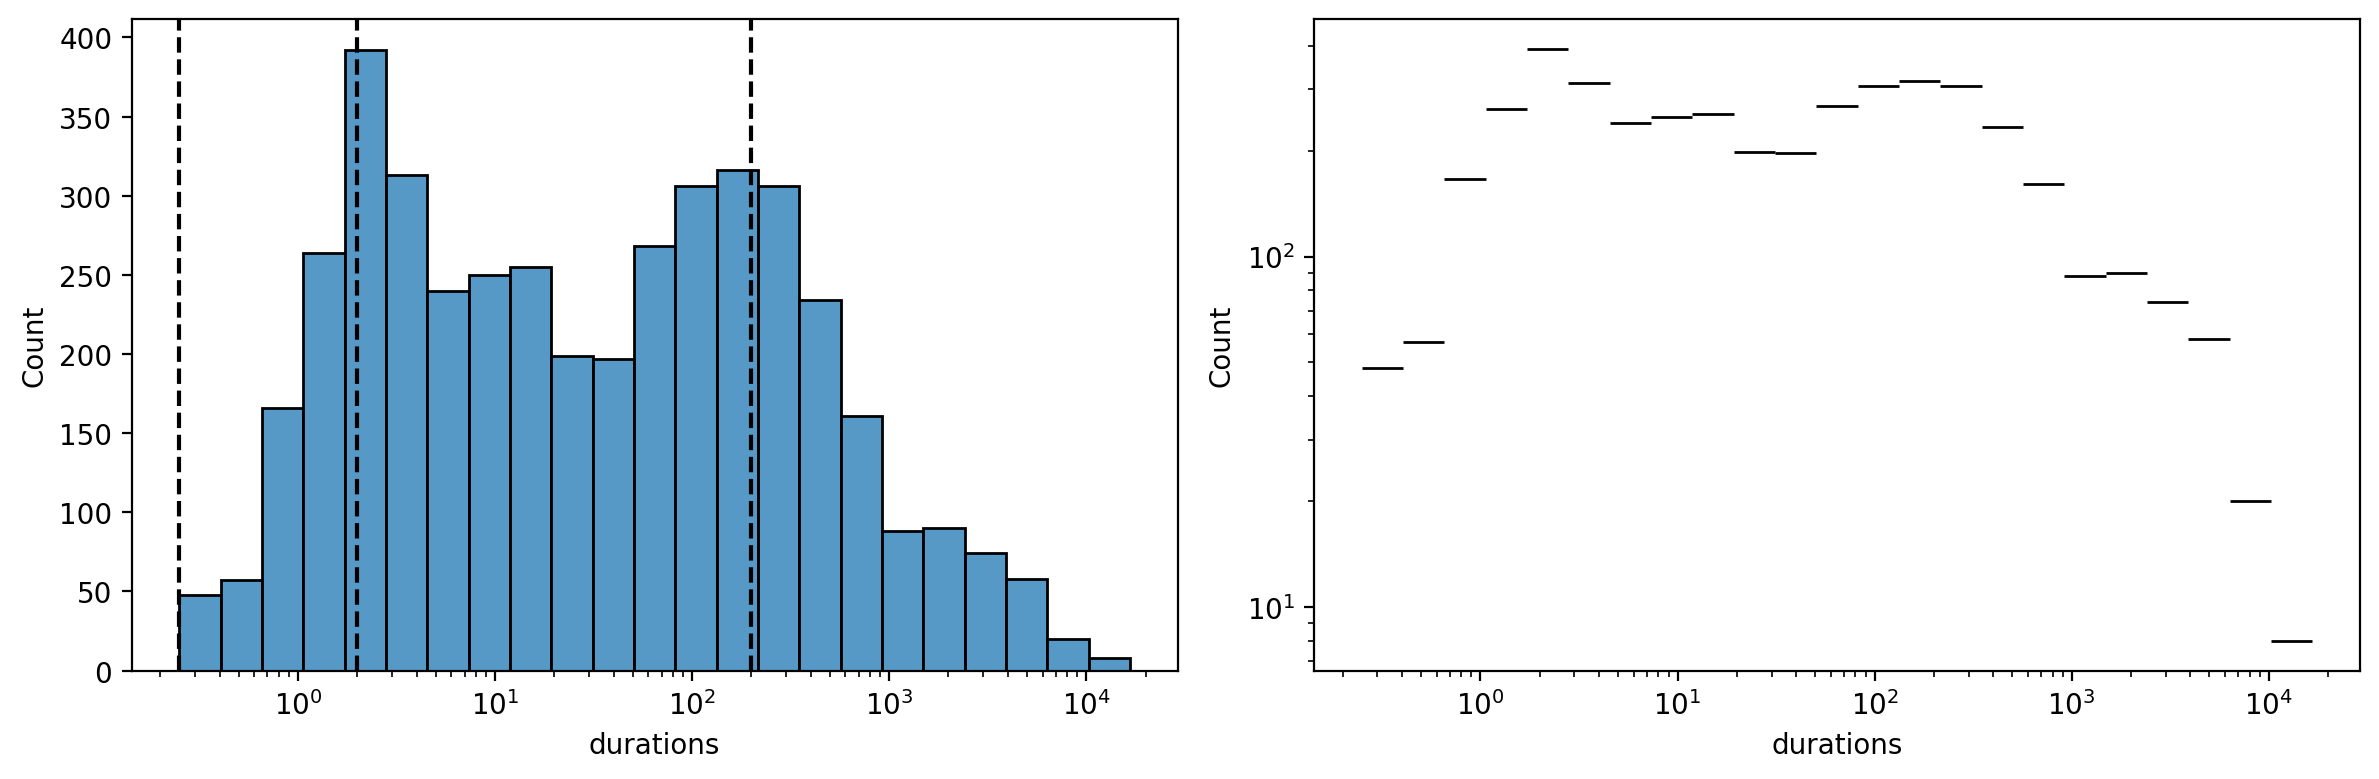

In [125]:
fig, ax=plt.subplots(nrows=1, ncols=2,figsize=(12, 4), dpi=200)
sns.histplot(data=tempo.events_table, x='durations', ax=ax[0], log_scale=(True, False))
sns.histplot(data=tempo.events_table, x='durations', ax=ax[1], log_scale=(True, True))
ax[0].axvline(0.25, color='k', linestyle='--')
ax[0].axvline(2, color='k', linestyle='--')
ax[0].axvline(200, color='k', linestyle='--')

plt.tight_layout()
plt.show()

There are clearly three modes in the edge duration distribution, one that is around 0.25 secs and another at 2 and 200 seconds. We will use these scales for later stages.


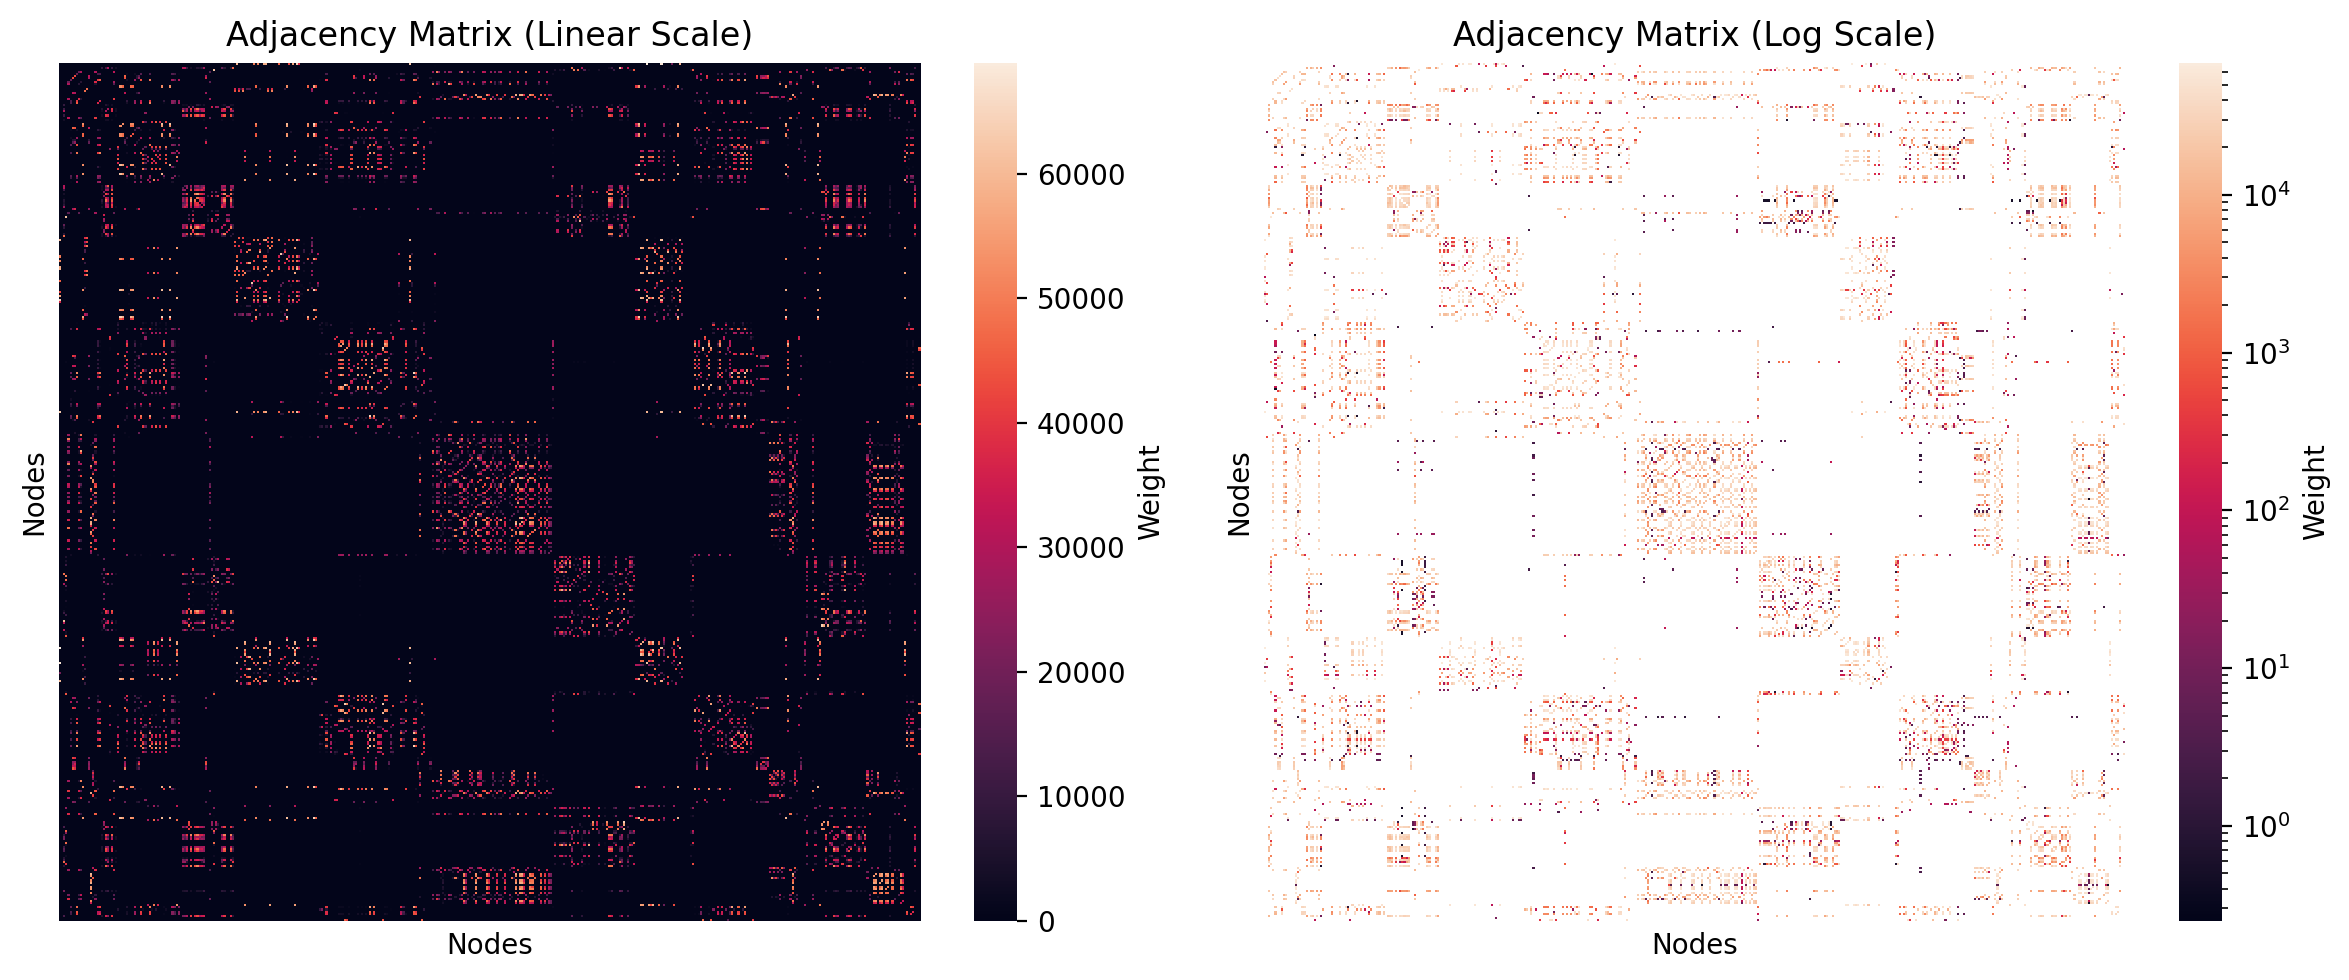

In [38]:
A = tempo.compute_static_adjacency_matrix()
A_dense = A.toarray()

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, dpi=200, figsize=(12, 5))

sns.heatmap(A_dense, ax=ax1, cbar_kws={'label': 'Weight'})
ax1.set_xlabel('Nodes')
ax1.set_ylabel('Nodes')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Adjacency Matrix (Linear Scale)')



A_log = A_dense.copy()
A_log[A_log == 0] = np.nan 

sns.heatmap(A_log, ax=ax2, norm=LogNorm(), cbar_kws={'label': 'Weight'})
ax2.set_xlabel('Nodes')
ax2.set_ylabel('Nodes')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title('Adjacency Matrix (Log Scale)')

plt.tight_layout()

We then transform it to a Networkx object to visualise and perform other algorithms and measure computation. 

In [41]:
static=nx.from_numpy_array(A.toarray())

In [59]:
nx.is_connected(static)

False

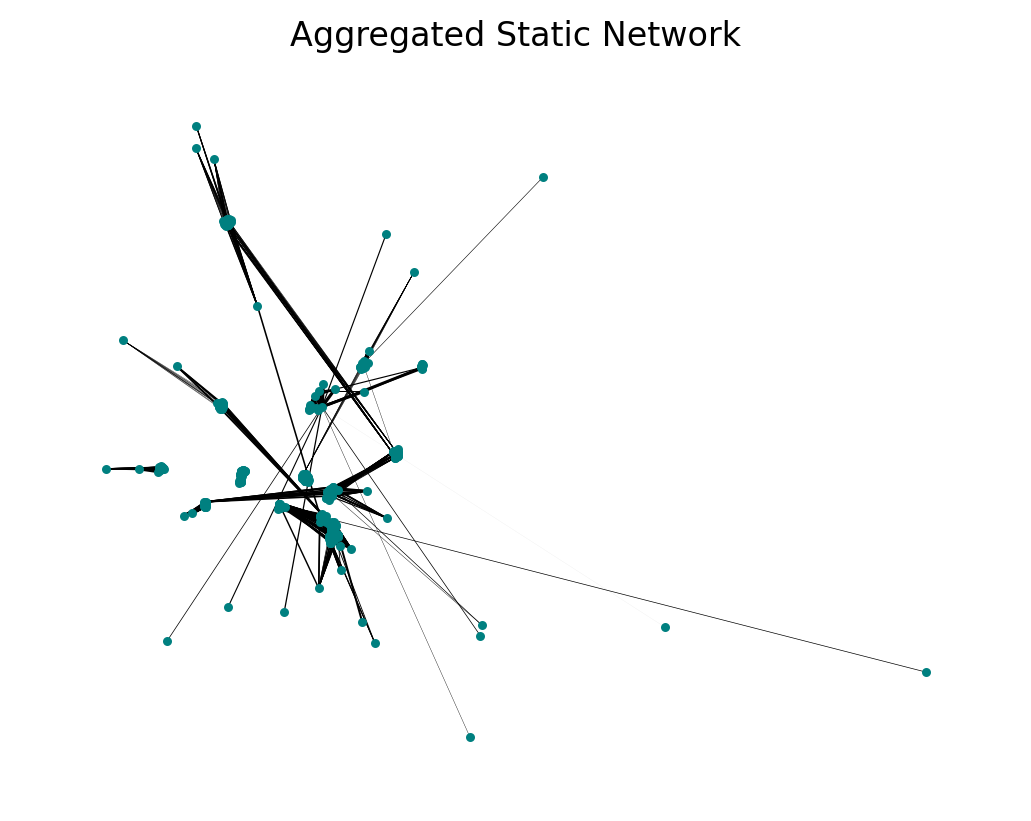

In [62]:
fig, ax=plt.subplots(nrows=1, ncols=1, dpi=200)

pos=nx.spring_layout(static, seed=412)
weights = [static[u][v]["weight"] for u, v in static.edges()]
max_w = max(weights)
widths = [ 2*np.log10(w) / np.log10(max_w) for w in weights] 

nx.draw(static, pos, with_labels=False, width=widths, node_color="teal", node_size=5)


plt.title("Aggregated Static Network")
plt.show()

The network is not connected, and it is clearly modular. 

To find the start and end of the temporal network, equivalently, the minimum start time and maximum end time, we can query the network directly:



In [64]:
print("Start:", tempo.start_time)
print("End:", tempo.end_time)

Start: 11.13
End: 97881.77


Text(0, 0.5, 'Number of active nodes')

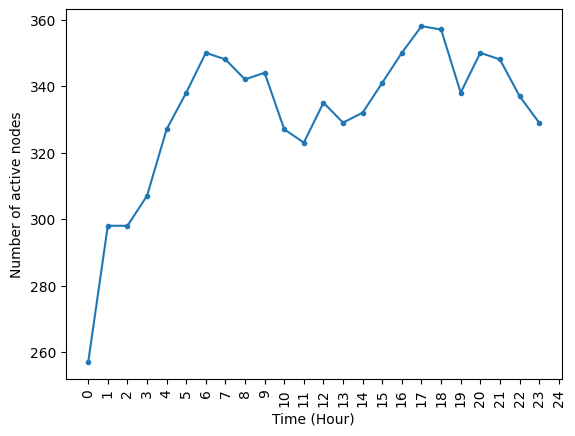

In [ ]:
t=np.arange(0, 24*3600+1, 3600)
n_active=[tempo.num_active_nodes(t[i], t[i+1]) for i in range(len(t)-1)]
fig,ax=plt.subplots(nrows=1, ncols=1)
ax.plot(t[:-1], n_active, marker='.')

ax.set_xticks(t)
ax.set_xticklabels([i//3600 for i in t ], rotation=90)
ax.set_xlabel('Time (Hour)')
ax.set_ylabel('Number of active nodes')

Text(0, 0.5, 'Number of active events')

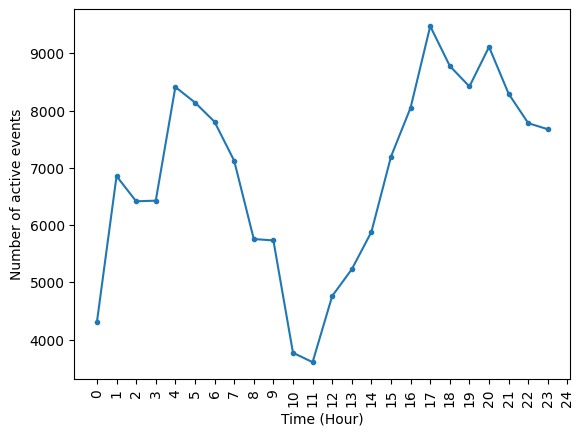

In [ ]:
t=np.arange(0, 24*3600+1, 3600)
n_edge_active=[tempo.num_active_edges( t[i], t[i+1]) for i in range(len(t)-1)]

fig,ax=plt.subplots(nrows=1, ncols=1)
ax.plot(t[:-1], n_edge_active, marker='.')

ax.set_xticks(t)
ax.set_xticklabels([i//3600 for i in t ], rotation=90)
ax.set_xlabel('Time (Hour)')
ax.set_ylabel('Number of active events')

The activity of events and nodes depends on the time of the day. Now we want to compute the forward transition matrices by first computing the laplacians. 

In [88]:
tempo.compute_laplacian_matrices()

2026-05-13 13:55:41,929 - INFO - tempnet\temporal_network.py:1267 - PID:15340 - Computing Laplacians
2026-05-13 13:55:41,971 - INFO - tempnet\temporal_network.py:1326 - PID:15340 - 0 over 1977
2026-05-13 13:55:41,971 - INFO - tempnet\temporal_network.py:1330 - PID:15340 - 0.00s
2026-05-13 13:55:47,760 - INFO - tempnet\temporal_network.py:1326 - PID:15340 - 1000 over 1977
2026-05-13 13:55:47,760 - INFO - tempnet\temporal_network.py:1330 - PID:15340 - 5.79s
2026-05-13 13:55:54,578 - INFO - tempnet\temporal_network.py:1377 - PID:15340 - Finished in 12.611711978912354


We then proceed to computing the forward transition matrix for 3 time scales.

In [121]:
scales=[1e-5, 1e-3, 1]
for i, s in tqdm(enumerate(scales)):
    tempo.compute_inter_transition_matrices(lamda=s)

forward_transition_matrices=[reduce(lambda a, b: a @ b, tempo.inter_T[s]) for s  in scales ]

3it [01:07, 22.63s/it]


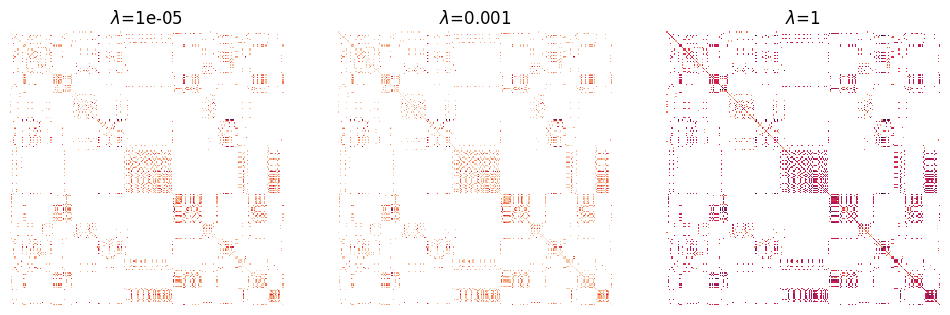

In [124]:
fig, ax=plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

for i, (lamda, matrix) in enumerate(zip(scales, forward_transition_matrices) ):
    sns.heatmap(matrix.toarray(), ax=ax[i], square=True, cbar=False, vmin=0 , vmax=1, norm=LogNorm()
                )
    ax[i].set_title(rf'$\lambda$={lamda}')
    ax[i].set_xticks([])
    ax[i].set_yticks([])